## Load Libaries

In [1]:
from scipy import signal
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import resample
from preprocessing import Filtering
import pandas as pd
from pathlib import Path
import mne

# from utilities.visualize_data import visualize_EMG

## Constants

In [2]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 2
EEG_HIGHCUT = 32

EMG_NUM_CH = 3          # 3
EEG_NUM_CH = 16

NUM_EPOCHS = 30         # 35
TOTAL_EPOCHS = 90      # 105
TRIAL_PERIOD = 8        # 9

RMS_SAMPLING_WINDOW = 200
RMS_WINDOW_STEPSIZE = 50

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Fz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]

EMG_CH_NAMES = [
    'Channel 1 : Palmaris longus',
    'Channel 2 : Flexor digitorum superficialis',
    'Channel 3 : Flexor pollicis longus',
]

## Functions

In [ ]:
def trim_trial_periods(EEG_bandpass : np.ndarray,
                       all_markers: np.ndarray,
                       markers_idx: np.ndarray,
                       trial_period : int = 8,
                       trim_period : int = 3,
                       fs : int = 125,
                       extract_event : str = 'ALL') -> np.ndarray:
    """
    Trims the trial periods from the markers array.
    Parameters
    ----------

    EEG_bandpass : np.ndarray 
        Input of EEG data bandpass filtered
    all_markers : np.ndarray 
        Input of all markers array, including zero values
    markers_idx : np.ndarray
        Indices of non-zero markers. Can be extracted using np.nonzero()[0]
    
    Returns
    ----------
    :return: List of trimmed segments
    """
    if extract_event == 'ALL':
        START_TRIAL_MARKER = 10
        END_TRIAL_MARKER = {10, 201}
        trial_period = 8
    elif extract_event == 'REST':
        START_TRIAL_MARKER = 10
        END_TRIAL_MARKER = {20, 201}
        trial_period = 2
    elif extract_event == 'CONTRACT':
        START_TRIAL_MARKER = 20
        END_TRIAL_MARKER = {30, 201}
        trial_period = 4
    elif extract_event == 'RELEASE':
        START_TRIAL_MARKER = 30
        END_TRIAL_MARKER = {10, 201}
        trial_period = 2

    START_TRIM_MARKER = 101
    END_TRIM_MARKER = 102

    enter_trial = False
    enter_trim = False
    period_extrated = False
    st = 0
    ed = 0
    data = EEG_bandpass.copy()
    resampled_data = []


    # CHANGE START_TRIAL_MARKER, END_TRIAL_MARKER, TRIAL_PERIOD

    # Loop over non-zero indices where markers are present
    for i in range(len(markers_idx)):
        
        # Get the actual index in the markers array plus the next index
        mark_idx = markers_idx[i]
        mark_idx_next = markers_idx[i+1] if i + 1 < len(markers_idx) else None
        
        # Prevent iteration to go out of bounds. RELEASE require END_MARKER to trim the last trial
        if mark_idx_next is None and extract_event != 'RELEASE':
            continue

        # Enter only at the start of the first trim period
        elif all_markers[mark_idx] == START_TRIM_MARKER and not enter_trim:
            st = mark_idx
            enter_trim = True
        
        # Enter only in the end of the first trim period
        elif all_markers[mark_idx] == END_TRIM_MARKER and enter_trim:
            ed = mark_idx
            period_extrated = True
        
        # Enter only at the start of each trial period
        elif all_markers[mark_idx] == START_TRIAL_MARKER and not enter_trial:
            st = mark_idx
            enter_trial = True
            print('ENTER st')

        # Enter only at the end of each trial period when the START and END marker is different.
        elif all_markers[mark_idx] in END_TRIAL_MARKER and enter_trial:
            ed = mark_idx - 1
            period_extrated = True
            print('ENTER ed')
        
        # Enter only in the end of each trial period, if START and END marker belong to the same mark
        elif all_markers[mark_idx_next] in END_TRIAL_MARKER and enter_trial and START_TRIAL_MARKER in END_TRIAL_MARKER:
            ed = mark_idx_next - 1
            period_extrated = True
            
        if period_extrated:
            period_extrated = False
            
            if enter_trim:
                trim_data = data[st:ed, :]
                n_samples = trim_data.shape[0]
                real_fs = n_samples / trim_period
                target_len = int(np.round(n_samples * (fs / real_fs)))

                enter_trim = False
                #print(f'Trial from {st} to {ed}, len: {ed - st}')
                #print(f'Time period {trim_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')
                
            
            elif enter_trial:
                trim_data = data[st:ed, :]
                n_samples = trim_data.shape[0]
                real_fs = n_samples / trial_period
                target_len = int(np.round(n_samples * (fs / real_fs)))

                EEG_resampled = resample(trim_data, target_len, axis=0)
                resampled_data.append(EEG_resampled)                  
                
                enter_trial = False
                #print(f'Trial from {st} to {ed}, len: {ed - st}')
                #print(f'Time period {trial_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')
                
    
    return np.concatenate(resampled_data, axis=0)


In [93]:
def preprocessing_routine_marker(raw_eeg, 
                            bandpass_lowcut = 2, 
                            bandpass_highcut = 32,  
                            trial_period = 9,
                            fs = 125,
                            trim_period = 3,
                            marker_log : list = None,
                            extract_event : str = 'ALL'):
        '''
        Performs the full preprocessing routine:
        1) Notch + Bandpass filter
        2) Resample + z-score standardization + Secmentation into epochs

        :param dict raw_eeg: This holds keys for a specfic class (finger). NOTE - If raw_eeg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
        :param int bandpass_lowcut: Lowpass frequency
        :param int bandpass_highcut: Highpass frequency
        :param int num_channels: Number of activated channels
        :param int num_epochs: Number of epochs (trials) in the dataset
        :param int trial_period: Time of each epoch

        :return dict EEG_norm: Dict with normalized continuous EEG data - EEG_norm[keys()](samples, channels)
        :return dict EEG_epoch: Dict with epoched EEG data - EEG_epoch[keys()](epochs, samples_per_epoch, channels)
        :return dict EEG_epoch_mean: Dict with mean over epochs - EEG_epoch_mean[keys()](samples_per_mean_epoch, channels)
        '''

        # --------------------------------------------------
        # 1) NOTCH + BANDPASS FILTER
        # --------------------------------------------------


        EEG_filter_ins = Filtering(fs = fs)

        EEG_notch = None
        EEG_bandpass = None
        EEG_trim = None
        EEG_norm = None
        
        EEG_notch = EEG_filter_ins.notch(raw_eeg, cutoff=50, Q=30)
        EEG_bandpass, _ = EEG_filter_ins.butter_bandpass(EEG_notch, lowcut=bandpass_lowcut, highcut=bandpass_highcut, order=4)

        # --------------------------------------------------
        # 2) RESAMPLE + Trim
        # --------------------------------------------------
        markers_idx = np.nonzero(marker_log)[0]
        
        EEG_trim = trim_trial_periods(EEG_bandpass = EEG_bandpass, 
                                        all_markers = marker_log, 
                                        markers_idx = markers_idx, 
                                        trial_period = trial_period, 
                                        trim_period = trim_period, 
                                        fs = fs,
                                        extract_event = str.upper(extract_event))
        
        # --------------------------------------------------
        # 3) Z-SCORE STANDARDIZATION
        # --------------------------------------------------
        EEG_norm = EEG_filter_ins.zscore_within_channel(EEG_trim)

        return EEG_norm

def normalization(data):

    n_samples, n_channels = data.shape

    vmax = np.max(data)
    vmin = np.min(data)

    data_arr = []

    for ch in range(n_channels):
        sel_data = data[:, ch]

        data_norm = (sel_data - vmin) / (vmax - vmin)
        
        data_arr.append(data_norm)
    
    return np.array(data_arr).T


def sliding_rms(filt_emg, window_size=10, step_size=5):
    rms_vals_all = []
    for ch in range(filt_emg.shape[1]):
        rms_vals = []
        for start in range(0, len(filt_emg) - window_size + 1, step_size):
            window = filt_emg[start : start + window_size, ch]
            rms_vals.append(np.sqrt(np.mean(window**2)))
        rms_vals_all.append(rms_vals)
    return np.array(rms_vals_all).T

def preprocessing_routine(  raw_emg,
                            bandpass_lowcut = 20,
                            bandpass_highcut = 450,
                            num_epochs = 30,
                            trial_period = 8,
                            trim_period = 3):
    '''
    Performs the full preprocessing routine:
    1) Notch + Bandpass filter
    2) Resample + z-score standardization + Secmentation into epochs

    :param dict raw_emg: This holds keys for a specfic class (finger). NOTE - If raw_emg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
    :param int bandpass_lowcut: Lowpass frequency
    :param int bandpass_highcut: Highpass frequency
    :param int num_channels: Number of activated channels
    :param int num_epochs: Number of epochs (trials) in the dataset
    :param int trial_period: Time of each epoch

    :return dict EMG: Dict with normalized continuous EMG data - EMG[keys()](samples, channels)
    :return dict EMG_epoch: Dict with epoched EMG data - EMG_epoch[keys()](epochs, samples_per_epoch, channels)
    :return dict EMG_epoch_mean: Dict with mean over epochs - EMG_epoch_mean[keys()](samples_per_mean_epoch, channels)
    '''

    # ---------------------------#
    # 1) NOTCH + BANDPASS FILTER #
    # ---------------------------#
    fs = 2000    # resplace with self.fs
    EMG_filter_ins = Filtering(fs = fs)        
    
    EMG_notch = EMG_filter_ins.notch(raw_emg, cutoff=50, Q=30)
    EMG_bandpass, _ = EMG_filter_ins.butter_bandpass(EMG_notch, lowcut=bandpass_lowcut, highcut=bandpass_highcut, order=4)

    # --------#
    # 2) TRIM #
    # --------#
    trim_idx_102 = fs * trim_period
    trim_idx_201 = (fs * trial_period * num_epochs) + trim_idx_102
    EMG_trim = EMG_bandpass[trim_idx_102 : trim_idx_201, :]
    print(f"Trim 102 idx {trim_idx_102}\n"
          f"Trim 201 idx {trim_idx_201}\n"
          f'EMG_trim shape: {EMG_trim.shape}\n')

    # ------------#
    # 3) RESAMPLE #
    # ------------#
    total_time = num_epochs * trial_period                              # total time in seconds.
    n_samples = EMG_trim.shape[0]
    real_fs = n_samples / total_time                              # Real frequency
    target_len = int( np.round(n_samples  * (fs / real_fs)) )            # The correct number of samples for desired frequency

    if n_samples == target_len:
        resample_temp = EMG_trim
    else:
        resample_temp = resample(EMG_trim, target_len, axis = 0)
        print(f'Did resample from {n_samples} to {target_len}')
    
    EMG = EMG_filter_ins.zscore_within_channel(resample_temp)
    #EMG = normalization(resample_temp)

    print(f'Total Time {total_time} s\n'
        f'Real fs: {real_fs} Hz\n'
        f'Target len: {target_len}\n'
        f'EMG original len: {n_samples}\n')

    return EMG

def preprocessing_routine_rms(
                            raw_emg,
                            bandpass_lowcut = 20,
                            bandpass_highcut = 450,
                            num_epochs = 30,
                            trial_period = 8,
                            trim_period = 3,
                            sample_window = 200,
                            window_stepsize = 50):
    '''
    Performs the full preprocessing routine:
    1) Notch + Bandpass filter
    2) Resample + z-score standardization + Secmentation into epochs

    :param dict raw_emg: This holds keys for a specfic class (finger). NOTE - If raw_emg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
    :param int bandpass_lowcut: Lowpass frequency
    :param int bandpass_highcut: Highpass frequency
    :param int num_channels: Number of activated channels
    :param int num_epochs: Number of epochs (trials) in the dataset
    :param int trial_period: Time of each epoch
    :param int sample_window: Amount of samples in the sliding window.
    :param int window_stepsize: Sliding window step size. This means the step size over the signal.

    :return dict RMS: Dict with normalized continuous RMS data - RMS[keys()](samples, channels)
    :return dict RMS_epoch: Dict with epoched RMS data - RMS_epoch[keys()](epochs, samples_per_epoch, channels)
    :return dict RMS_epoch_mean: Dict with mean over epochs - RMS_epoch_mean[keys()](samples_per_mean_epoch, channels)
    '''

    # ---------------------------#
    # 1) NOTCH + BANDPASS FILTER #
    # ---------------------------#
    # REPLACE WITH self.fs
    fs = 2000
    EMG_filter_ins = Filtering(fs = fs)

    EMG_notch = EMG_filter_ins.notch(raw_emg, cutoff=50, Q=30)
    EMG_bandpass, _ = EMG_filter_ins.butter_bandpass(EMG_notch, lowcut=bandpass_lowcut, highcut=bandpass_highcut, order=4)

    # --------#
    # 2) TRIM #
    # --------#
    trim_idx_102 = fs * trim_period
    trim_idx_201 = (fs * trial_period * num_epochs) + trim_idx_102
    EMG_trim = EMG_bandpass[trim_idx_102 : trim_idx_201, :]
    print(f"Trim 102 idx {trim_idx_102}\n"
          f"Trim 201 idx {trim_idx_201}\n"
          f'EMG_trim shape: {EMG_trim.shape}\n')

    # -------#
    # 3) RMS #
    # -------#
    RMS_temp = sliding_rms(filt_emg = EMG_trim, window_size = sample_window, step_size = window_stepsize)

    # ------------#
    # 4) RESAMPLE #
    # ------------#
    total_time = num_epochs * trial_period                              # total time in seconds.
    n_samples = RMS_temp.shape[0]
    real_fs = n_samples / total_time                              # Real frequency
    ceil_fs = int( np.ceil(real_fs) )                                   # Get as close to the real fs
    target_len = int( np.round(n_samples  * (ceil_fs / real_fs)) )            # The correct number of samples for desired frequency


    if n_samples == target_len:
        resample_temp = RMS_temp
    else:
        resample_temp = resample(RMS_temp, target_len, axis = 0)
        print(f'Did resample from {n_samples} to {target_len}')

    RMS = EMG_filter_ins.zscore_within_channel(resample_temp)
    #RMS = normalization(resample_temp)

    print(f'Total Time {total_time} s\n'
        f'Real fs: {real_fs} Hz\n'
        f'Target len: {target_len}\n'
        f'EMG original len: {EMG_trim.shape[0]}\n'
        f'RMS len: {RMS.shape[0]}')

    return RMS

## Load data EEG

In [ ]:


def load_datasets(path_to_data_files : list, extract_event : str):

    all_data = []
    for data_file in path_to_data_files:
    
        EEG_df = pd.read_csv(data_file)
        EEG_raw = EEG_df.iloc[:, 1:17].to_numpy()
        EEG_marker_log = EEG_df.iloc[:, -1].to_numpy()
        
        # Preprocessing
        EEG_filt = preprocessing_routine_marker(raw_eeg=EEG_raw, 
                                bandpass_lowcut = 2,
                                bandpass_highcut = 32,
                                trial_period = TRIAL_PERIOD, 
                                fs = EEG_FREQ,
                                trim_period = 3, 
                                marker_log = EEG_marker_log,
                                extract_event = extract_event)

        all_data.append(EEG_filt)

    all_data_array = np.array(all_data)
    EEG = all_data_array.reshape(-1, EEG_NUM_CH)
    print(f"Reshaped data shape: {EEG.shape}")

    EEG_samples_per_epoch = EEG.shape[0] // TOTAL_EPOCHS      
    print(f"Samples per epoch: {EEG_samples_per_epoch}")

    EEG_epoch = EEG.reshape(TOTAL_EPOCHS, EEG_samples_per_epoch, EEG_NUM_CH)

    EEG_epoch_mean = EEG_epoch.mean(axis=0)
    print(f"Epoched data shape: {EEG_epoch.shape}")
    print(f"Mean epoch data shape: {EEG_epoch_mean.shape}")

    return EEG, EEG_epoch, EEG_epoch_mean

subject_ID = 'subject_0'

#file_path = str(Path().resolve().parent) + f'/experiment/data/{subject_ID}/EEG/' + list_of_filenames[data_nr] + '.csv'


INDEX, INDEX_epoch, INDEX_epoch_mean = load_datasets(files, 'contract')
#THUMB, THUMB_epoch, THUMB_epoch_mean = load_datasets(thumb_name)


Trial from 0 to 421, len: 421
Time period 3
 Real fs: 140.33333333333334 Hz
 Target len: 375
 Original len: 421
ENTER st
ENTER ed
Trial from 661 to 1141, len: 480
Time period 4
 Real fs: 120.0 Hz
 Target len: 500
 Original len: 480
ENTER st
ENTER ed
Trial from 1623 to 2163, len: 540
Time period 4
 Real fs: 135.0 Hz
 Target len: 500
 Original len: 540
ENTER st
ENTER ed
Trial from 2645 to 3125, len: 480
Time period 4
 Real fs: 120.0 Hz
 Target len: 500
 Original len: 480
ENTER st
ENTER ed
Trial from 3667 to 4147, len: 480
Time period 4
 Real fs: 120.0 Hz
 Target len: 500
 Original len: 480
ENTER st
ENTER ed
Trial from 4629 to 5169, len: 540
Time period 4
 Real fs: 135.0 Hz
 Target len: 500
 Original len: 540
ENTER st
ENTER ed
Trial from 5651 to 6131, len: 480
Time period 4
 Real fs: 120.0 Hz
 Target len: 500
 Original len: 480
ENTER st
ENTER ed
Trial from 6673 to 7153, len: 480
Time period 4
 Real fs: 120.0 Hz
 Target len: 500
 Original len: 480
ENTER st
ENTER ed
Trial from 7635 to 8175,

In [161]:
from typing import List, Union

def find_flex_files(
    base_dir: Path,
    subjects: List[str],
    modality: str,
    fingers: Union[str, List[str]],
    prefix: str = "flex"
) -> List[Path]:
    """
    Find flex CSV files for selected subjects, modality, and fingers.

    Parameters
    ----------
    base_dir : Path
        Root directory of datasets (e.g. Path('experiment/data'))
    subjects : list[str]
        List like ['subject_0', 'subject_1']
    modality : str
        'EEG' or 'EMG'
    fingers : str or list[str]
        'index', 'thumb', or ['index', 'thumb']
    prefix : str
        Filename prefix (default='flex')

    Returns
    -------
    list[Path]
        List of matching CSV file paths
    """

    if isinstance(fingers, str):
        fingers = [fingers]

    paths = []

    for subject in subjects:
        data_dir = base_dir / subject / modality
        if not data_dir.exists():
            raise FileNotFoundError(f'{data_dir} - does not exists')

        for finger in fingers:
            pattern = f"{prefix}_{finger}_finger*.csv"
            paths.extend(data_dir.glob(pattern))

    return sorted(paths)

base_dir = Path().resolve().parent / 'experiment/data'

files = find_flex_files(
    base_dir = base_dir,
    subjects=["subject_0"],
    modality="EEG",
    fingers=["index"]
)



## Load EMG data

In [7]:
## For subject_0

# For index
data_name = ['flex_index_finger_2026-01-27 14-41-39', 'flex_index_finger_2026-01-27 15-07-10', 'flex_index_finger_2026-01-27 15-15-34']

# For thumb
data_name = ['flex_thumb_finger_2026-01-27 15-31-33', 'flex_thumb_finger_2026-01-27 15-37-41', 'flex_thumb_finger_2026-01-27 15-46-50']
# For wrist EMG 
#data_name = ['flex_index_finger_2025-11-28 16-41-45', 'flex_index_finger_2025-11-28 16-47-44', 'flex_index_finger_2025-11-28 16-53-44']

all_data_EMG = []
all_data_RMS = []

for data_nr in range(len(data_name)):
    file_path = str(Path().resolve().parent) + '/experiment/data/subject_0/EMG/' + data_name[data_nr] + '.csv'
    EMG_df = pd.read_csv(file_path)
    EMG_raw = EMG_df.to_numpy()
    
    print(f"raw data shape: {EMG_raw.shape}\n")
    
    # Preprocessing
    EMG_pre = preprocessing_routine(raw_emg=EMG_raw, 
                            bandpass_lowcut = 20,
                            bandpass_highcut = 450,
                            num_epochs = NUM_EPOCHS,
                            trial_period = TRIAL_PERIOD,
                            trim_period = 3)

    RMS_pre = preprocessing_routine_rms(raw_emg = EMG_raw,
                                        bandpass_lowcut = 20,
                                        bandpass_highcut = 450,
                                        num_epochs = NUM_EPOCHS,
                                        trial_period = TRIAL_PERIOD,
                                        trim_period = 3,
                                        sample_window = 200,
                                        window_stepsize = 50)
    all_data_EMG.append(EMG_pre)
    all_data_RMS.append(RMS_pre)

all_data_array_EMG = np.array(all_data_EMG)
all_data_array_RMS = np.array(all_data_RMS)

EMG = all_data_array_EMG.reshape(-1, EMG_NUM_CH)
RMS = all_data_array_RMS.reshape(-1, EMG_NUM_CH)

print(f"\nReshaped EMG data shape: {EMG.shape}")
print(f"Reshaped RMS data shape: {RMS.shape}")

# EPOCHS
EMG_samples_per_epoch = EMG.shape[0] // TOTAL_EPOCHS
EMG_epoch = EMG.reshape(TOTAL_EPOCHS, EMG_samples_per_epoch, EMG_NUM_CH)
EMG_epoch_mean = EMG_epoch.mean(axis = 0)

RMS_samples_per_epoch = RMS.shape[0] // TOTAL_EPOCHS
RMS_epoch = RMS.reshape(TOTAL_EPOCHS, RMS_samples_per_epoch, EMG_NUM_CH)
RMS_epoch_mean = RMS_epoch.mean(axis = 0)

print(f"\nSamples per epoch: {EMG_samples_per_epoch}")
print(f"Epoched data shape: {EMG_epoch.shape}")
print(f"Mean epoch data shape: {EMG_epoch_mean.shape}")
print(f'RMS resample shape: {RMS.shape}\n')
print(f'RMS epoch shape: {RMS_epoch.shape}\n')
print(f'RMS mean epoch shape: {RMS_epoch_mean.shape}\n')

raw data shape: (491500, 3)

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600
Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600
raw data shape: (491500, 3)

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600
Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600
raw data shape: (491500, 3)

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 95

## Perform ICA

In [57]:
ch_names = [f"ch{i}" for i in range(EEG.shape[1])]
ch_types = ["eeg"] * EEG.shape[1]
sfreq = 125

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(EEG.T, info)

Creating RawArray with float64 data, n_channels=16, n_times=90000
    Range : 0 ... 89999 =      0.000 ...   719.992 secs
Ready.


In [58]:
ica = mne.preprocessing.ICA(
    n_components=0.77,   # keep 99% variance OR use a fixed number like 15
    method='fastica',
    max_iter = 1000,
    random_state=97
)

reject = dict(eeg = 80)
ica.fit(raw, reject=None)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by explained variance: 2 components
Fitting ICA took 0.2s.


C:\Users\Bruger\AppData\Local\Temp\ipykernel_17780\107160551.py:9: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, reject=None)


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,2 iterations on raw data (90000 samples)
ICA components,2
Available PCA components,16
Channel types,eeg
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=2, n_times=90000
    Range : 0 ... 89999 =      0.000 ...   719.992 secs
Ready.


<Figure size 640x480 with 0 Axes>

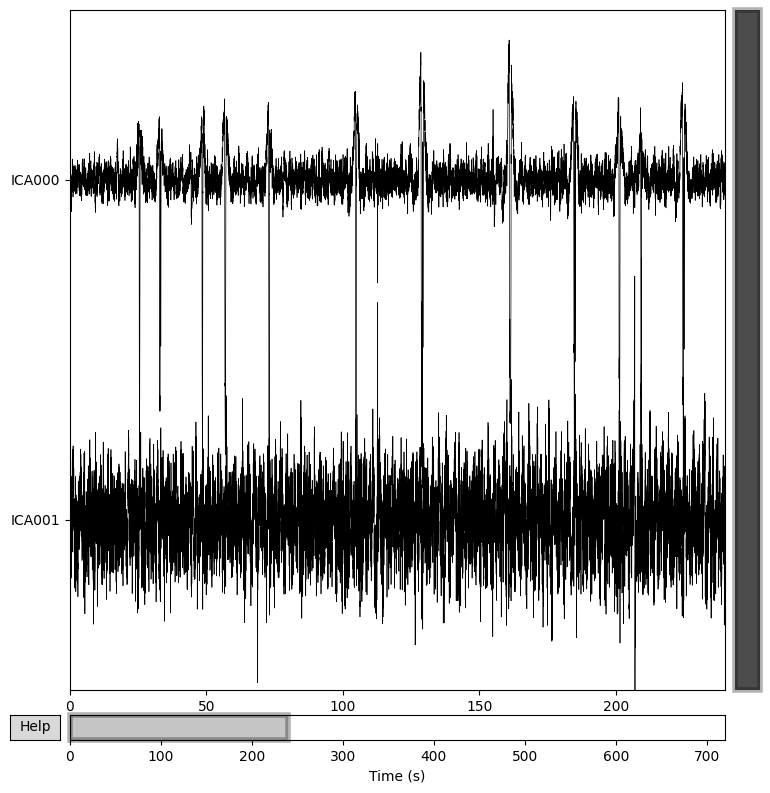

In [60]:
plt.figure()
ica.plot_sources(inst = raw, picks = None, start = 0, stop = 240, theme = 'dark')
plt.show(False)

In [61]:
ica.exclude = [0]
raw_clean = ica.apply(raw.copy())

raw.get_data().shape[1] / 125

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 16 PCA components


720.0

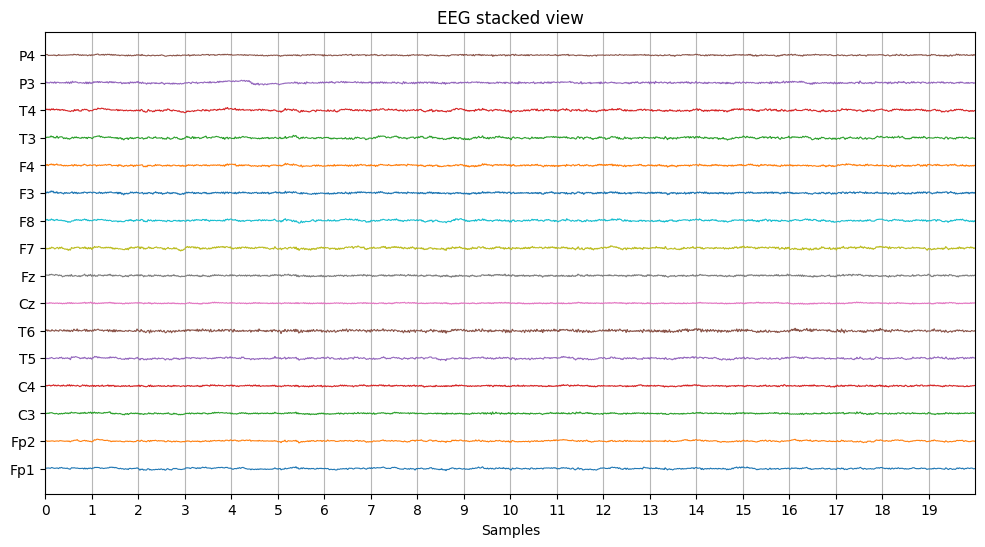

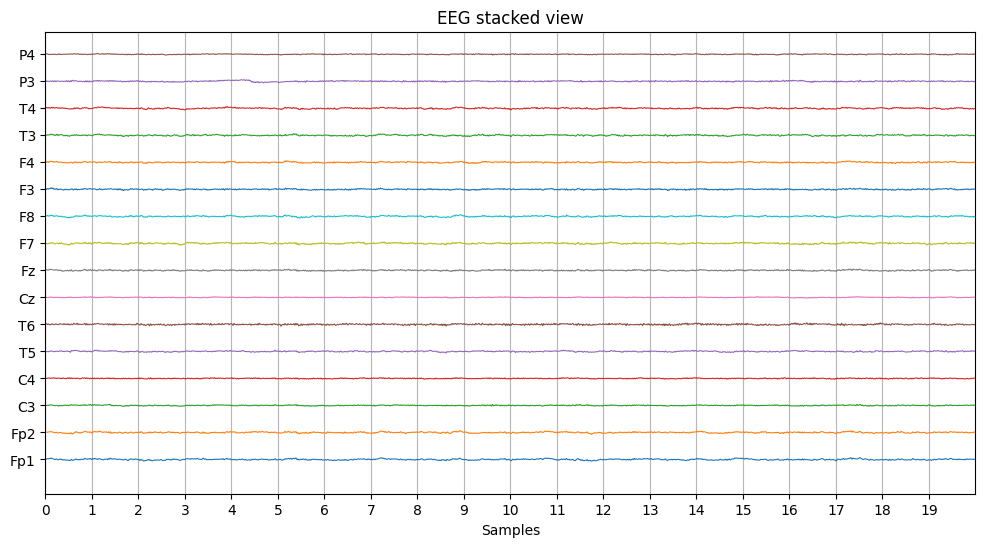

In [62]:
def plot_eeg_stack(data, sfreq, ch_names=None, seconds=240):
    """
    data : (samples, channels)  <-- your X or raw.get_data().T
    seconds : duration to show from start
    """

    n_samples = int(seconds * sfreq)
    data = data[:n_samples]
    time = np.arange(data.shape[0]) / sfreq

    yticks = []
    ylabels = []

    # scale channels to avoid overlap
    offset = np.max(np.abs(data)) * 2

    plt.figure(figsize=(12, 6))
    for i in range(data.shape[1]):
        y_offset = i * offset
        plt.plot(time, data[:, i] + y_offset, linewidth=0.8)

        yticks.append(y_offset)
        if ch_names:
            ylabels.append(ch_names[i])
        else:
            ylabels.append(f'ch{i}')

    plt.yticks(yticks, ylabels)
    plt.title("EEG stacked view")
    plt.xlabel("Samples")
    plt.grid(True, axis='x', alpha=0.9)
    plt.xticks(np.arange(0, 20, 1))
    plt.xlim([0, 20])
    plt.show()

plot_eeg_stack(raw_clean.get_data().T, sfreq=125, ch_names = EEG_CH_NAMES)
plot_eeg_stack(raw.get_data().T, sfreq=125, ch_names = EEG_CH_NAMES)

In [63]:
EEG_samples_per_epoch_mne = len(raw_clean) // TOTAL_EPOCHS      
print(f"Samples per epoch: {EEG_samples_per_epoch_mne}")

EEG_epoch_mne = raw_clean.get_data().T.reshape(TOTAL_EPOCHS, EEG_samples_per_epoch_mne, EEG_NUM_CH)

EEG_epoch_mean_mne = EEG_epoch_mne.mean(axis=0)
print(f"Epoched data shape: {EEG_epoch_mne.shape}")
print(f"Mean epoch data shape: {EEG_epoch_mean_mne.shape}")

Samples per epoch: 1000
Epoched data shape: (90, 1000, 16)
Mean epoch data shape: (1000, 16)


# Plot

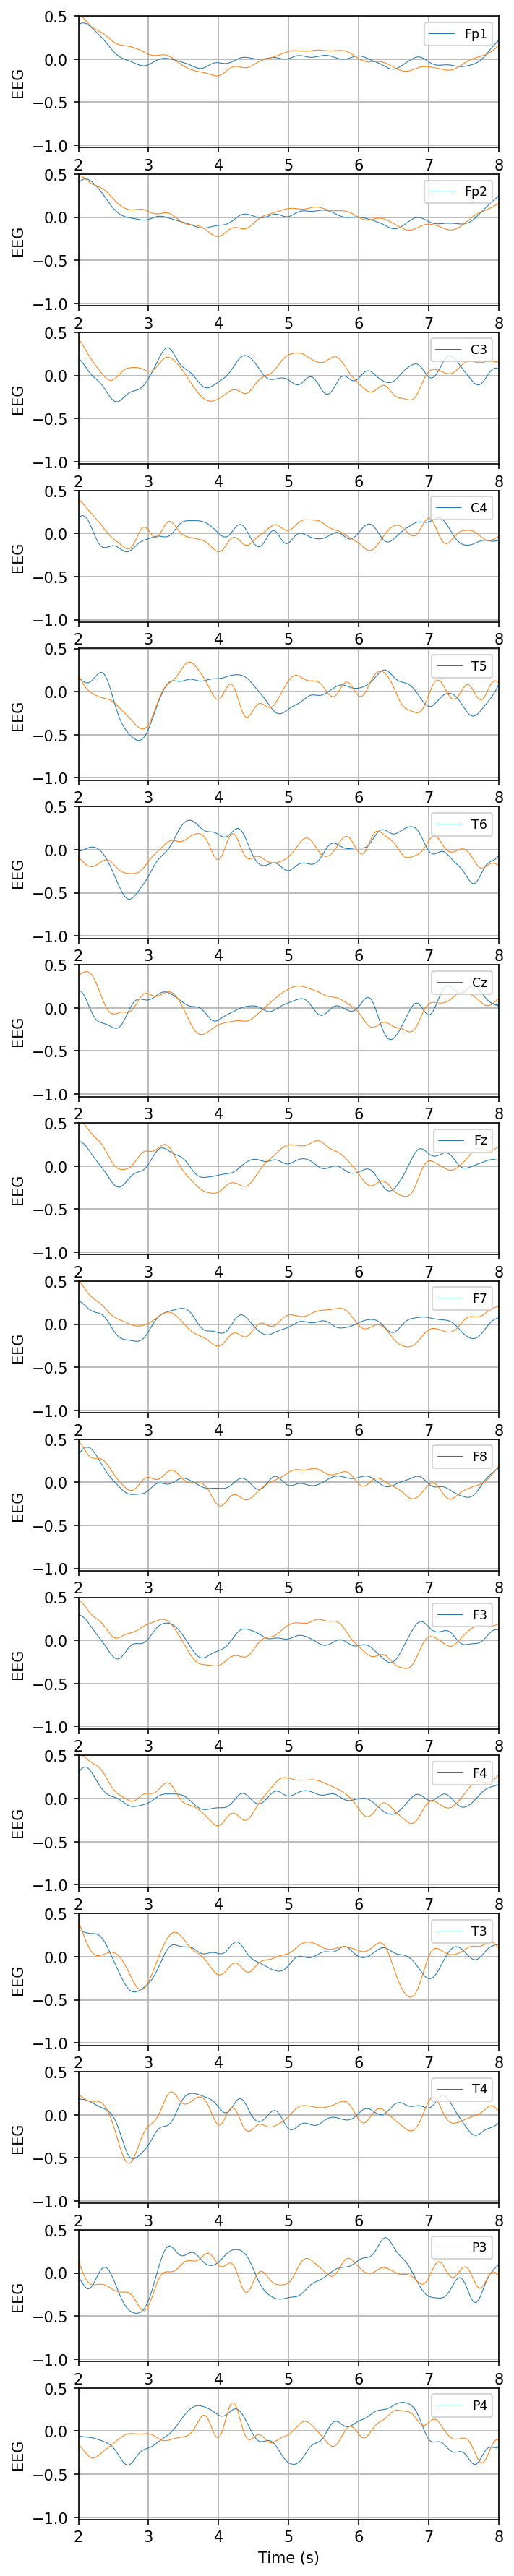

In [76]:
def plot_eeg(eeg, fs = 125, n_samples = 1000):
    ymax = np.max(eeg)
    ymin = np.min(eeg)
    xmax = 8
    xmin = 2

    fig, axs = plt.subplots(16, 1, figsize=(5, 30), dpi=150)

    time = np.arange(n_samples) / fs

    for ch in range(16):
        ax = axs[ch]
        EEG = eeg[:, ch]

        ax.plot(time, EEG, linewidth=0.5)

        ax.set_ylim([ymin, ymax])
        ax.set_xlim([xmin, xmax])
        ax.grid()

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('EEG')
        ax.legend([EEG_CH_NAMES[ch]], loc='upper right', fontsize='small')
    
    fig.tight_layout()

def plot_index_thumb(index, thumb, fs = 125, n_samples = 1000):
    ymax = np.max(index)
    ymin = np.min(index)
    xmax = 8
    xmin = 2

    fig, axs = plt.subplots(16, 1, figsize=(5, 30), dpi=150)

    time = np.arange(n_samples) / fs

    for ch in range(16):
        ax = axs[ch]
        sel_index = index[:, ch]
        sel_thumb = thumb[:, ch]

        ax.plot(time, sel_index, linewidth=0.5)
        ax.plot(time, sel_thumb, linewidth=0.5)

        ax.set_ylim([ymin, ymax])
        ax.set_xlim([xmin, xmax])
        ax.grid()

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('EEG')
        ax.legend([EEG_CH_NAMES[ch]], loc='upper right', fontsize='small')
    
filt_ins = Filtering(125)

#plot_eeg(filt_ins.zscore_within_channel(EEG_epoch_mean_mne), n_samples = 1000)
plot_index_thumb(INDEX_epoch_mean, THUMB_epoch_mean)

[0.000000e+00 5.000000e-04 1.000000e-03 ... 7.199985e+02 7.199990e+02
 7.199995e+02]


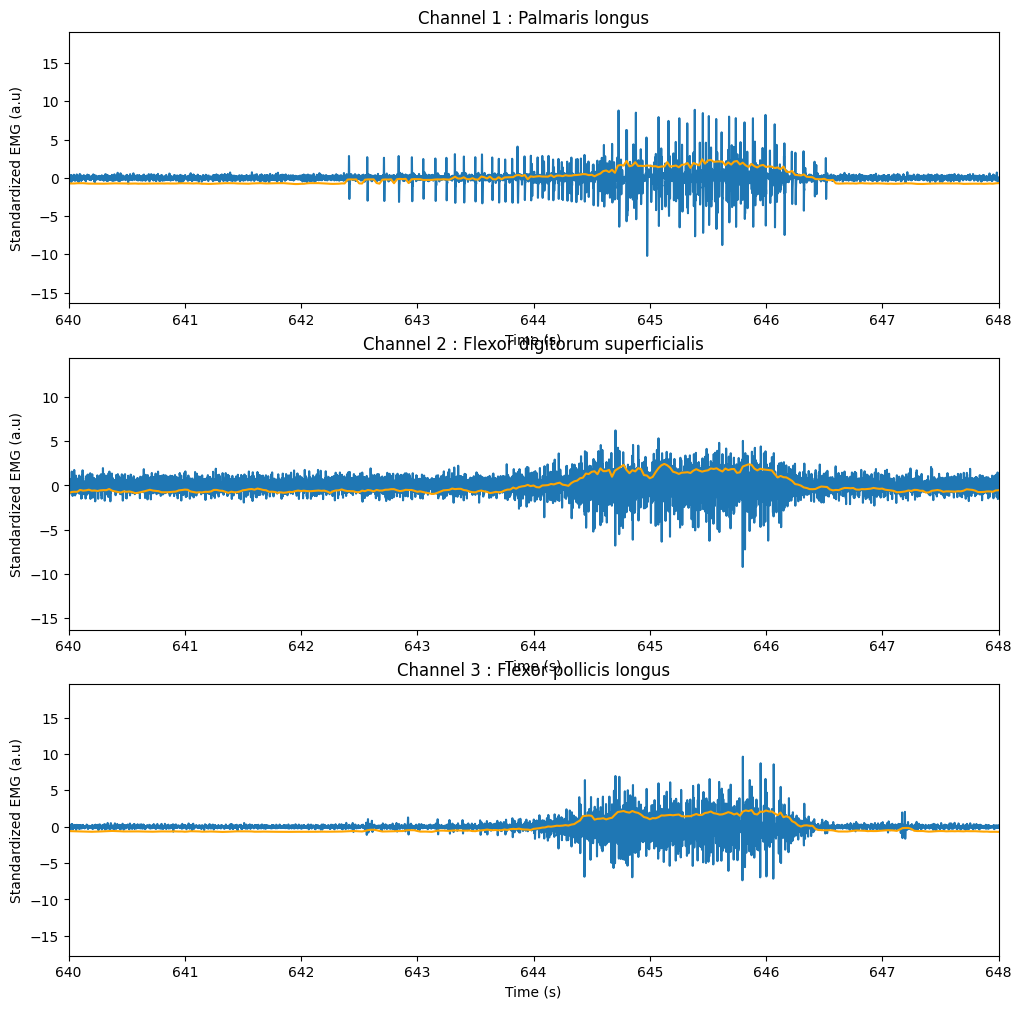

In [21]:
def plot_emg_and_rms(emg_data, rms_data):
    time = np.arange(emg_data.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms_data.shape[0]) * (RMS_window_size/4) + RMS_window_size/4) / EMG_FREQ
    print(time)
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))  # Before 210, 160
    for ch in range(EMG_NUM_CH):
        axs[ch].plot(time, emg_data[:, ch], label='Z-scored EMG')
        axs[ch].plot(win_time, rms_data[:, ch], label='RMS EMG', color='orange')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Standardized EMG (a.u)')
        axs[ch].set_title(f'{EMG_CH_NAMES[ch]}')
        #axs[ch].set_ylim([-10, 15])
        axs[ch].set_xlim([8*80, 8*81])

        

def plot_emg(emg_data):
    time = np.arange(emg_data.shape[0]) / EMG_FREQ
    
    
    
    fig, axs = plt.subplots(3, 1, figsize=(6, 12))  # Before 210, 160
    for ch in range(EMG_NUM_CH):
        axs[ch].plot(time, emg_data[:, ch], label='Z-scored EMG')
    
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Standardized EMG (a.u)')
        axs[ch].set_title(f'{EMG_CH_NAMES[ch]}')
        #axs[ch].set_ylim([, 0.4])
        #axs[ch].set_xlim([0, 24])

plot_emg_and_rms(EMG, RMS)

# ERD/ERS/MRCP

In [79]:
import pywt

def compute_ERD_ERS_pfurtscheller(
    epoch,
    fs=125,
    baseline=(0, 2)
):
    """
    Classical Pfurtscheller ERD/ERS (band-power over time)

    Parameters
    ----------
    epoch : np.ndarray
        Shape (n_trials, n_samples, n_channels)
        Must already be band-pass filtered (e.g. 8-30 Hz)
    fs : int
        Sampling frequency
    baseline : tuple
        Baseline interval in seconds (start, end)

    Returns
    -------
    erd_ers : np.ndarray
        Shape (n_samples, n_channels)
        ERD/ERS (%) over time
    """

    eps = 1e-12

    b0 = int(baseline[0] * fs)
    b1 = int(baseline[1] * fs)

    # Instantaneous power
    power = epoch ** 2                        # (trials, samples, channels)

    # Mean across trials
    Act = np.mean(power, axis=0)              # (samples, channels)

    # Baseline reference (per channel)
    R = np.mean(Act[b0:b1, :], axis=0)        # (channels,)

    # ERD / ERS (%)
    erd_ers = (Act - R) / (R + eps) * 100

    return erd_ers

def plot_ERD_ERS(
    erd_ers,
    fs=125,
    channels=None,
    time_window=None,
    title="ERD/ERS (8-30 Hz)"
):
    """
    Plot ERD/ERS as line plots over time

    Parameters
    ----------
    erd_ers : np.ndarray
        Shape (n_samples, n_channels)
    fs : int
        Sampling frequency
    channels : list or None
        Channel indices to plot (None = all)
    time_window : tuple or None
        (start, end) in seconds
    title : str
    """

    n_samples, n_channels = erd_ers.shape
    time = np.arange(n_samples) / fs

    if time_window is not None:
        t0, t1 = time_window
        idx = (time >= t0) & (time <= t1)
        time = time[idx]
        erd_ers = erd_ers[idx, :]

    if channels is None:
        channels = range(n_channels)

    plt.figure(figsize=(10, 4))

    for ch in channels:
        plt.plot(time, erd_ers[:, ch], label=f"Ch {ch}", linewidth=2)

    plt.axhline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("ERD / ERS (%)")
    plt.title(title)
    plt.legend(frameon=False, ncol=3)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def compute_erd_ers_pywt(
    epochs,
    fs=125,
    freq_band=(8, 30),
    baseline=(0, 2),
    wavelet="cmor1.5-1.0"
):
    """
    Compute ERD/ERS using Continuous Wavelet Transform (CWT)

    Parameters
    ----------
    epochs : np.ndarray
        Shape (n_epochs, n_samples, n_channels)
    fs : int
        Sampling frequency (Hz)
    freq_band : tuple
        Frequency band of interest (Hz)
    baseline : tuple
        Baseline interval in seconds (start, end)
    wavelet : str
        Complex Morlet wavelet

    Returns
    -------
    erd_ers : np.ndarray
        Shape (n_samples, n_channels)
        ERD/ERS (%) averaged across epochs and frequencies
    """

    n_epochs, n_samples, n_channels = epochs.shape

    # Frequencies of interest
    freqs = np.linspace(freq_band[0], freq_band[1], 30)

    # Convert frequencies to scales
    scales = pywt.frequency2scale(wavelet, freqs / fs)

    # Baseline indices
    b0 = int(baseline[0] * fs)
    b1 = int(baseline[1] * fs)

    erd_ers_all = []

    for ch in range(n_channels):
        power_epochs = []

        for ep in range(n_epochs):
            X_signal = epochs[ep, :, ch]

            coef, _ = pywt.cwt(X_signal, scales, wavelet, sampling_period=1/fs)
            power = np.abs(coef) ** 2     # (freqs, samples)

            power_epochs.append(power)

        power_epochs = np.array(power_epochs)  # (epochs, freqs, samples)

        # Mean across epochs - (freqs, samples)
        power_mean = power_epochs.mean(axis=0)
        

        # Baseline power (per frequency)
        baseline_power = power_mean[:, b0:b1].mean(axis=1, keepdims=True)

        # ERD/ERS (%)
        erd_ers = (power_mean - baseline_power) / baseline_power * 100

        # Average across frequencies (8–30 Hz)
        erd_ers_band = erd_ers.mean(axis=0)  # (samples,)

        erd_ers_all.append(erd_ers_band)

    return np.stack(erd_ers_all, axis=1)  # (samples, channels)

def plot_wavelet_spectrogram(EEG_epochs, fs = 125):
    erd_ers = compute_erd_ers_pywt(epochs=EEG_epochs, fs = fs, freq_band=(8, 30), baseline=(0, 2), wavelet="cmor1.5-1.0")

    plt.figure(figsize=(10, 4))
    plt.imshow(
        erd_ers.T,             # IMPORTANT transpose
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        extent=[0, erd_ers.shape[0]/fs, 0, erd_ers.shape[1]]
    )
    plt.colorbar(label='ERD/ERS (%)')
    plt.xlabel("Time (s)")
    plt.ylabel("Channel")
    plt.title("ERD/ERS (8-30 Hz)")
    plt.show()

def compute_erd_ers_tf_pywt(
    epochs,
    fs=125,
    freq_band=(8, 30),
    n_freqs=30,
    baseline=(0, 2),
    wavelet="cmor1.5-1.0"
):
    """
    Compute time-frequency ERD/ERS per channel using CWT

    Returns
    -------
    erd_ers_tf : np.ndarray
        Shape (channels, freqs, samples)
    freqs : np.ndarray
        Frequencies (Hz)
    """

    n_epochs, n_samples, n_channels = epochs.shape

    freqs = np.linspace(freq_band[0], freq_band[1], n_freqs)
    scales = pywt.frequency2scale(wavelet, freqs / fs)

    b0 = int(baseline[0] * fs)
    b1 = int(baseline[1] * fs)

    erd_ers_tf = np.zeros((n_channels, n_freqs, n_samples))

    for ch in range(n_channels):
        power_epochs = []

        for ep in range(n_epochs):
            coef, _ = pywt.cwt(
                epochs[ep, :, ch],
                scales,
                wavelet,
                sampling_period=1/fs
            )
            power_epochs.append(np.abs(coef) ** 2)

        power_epochs = np.array(power_epochs)   # (epochs, freqs, samples)
        power_mean = power_epochs.mean(axis=0)  # (freqs, samples)

        baseline_power = power_mean[:, b0:b1].mean(axis=1, keepdims=True)

        erd_ers_tf[ch] = (power_mean - baseline_power) / baseline_power * 100

    return erd_ers_tf, freqs

def plot_wavelet_spectrogram_ft(EEG_epochs, ch = 0):
    erd_ers_tf, freqs = compute_erd_ers_tf_pywt(epochs = EEG_epochs, fs = 125, freq_band=(8, 30), n_freqs=30, baseline=(0, 2), wavelet="cmor1.5-1.0")
    time = np.arange(erd_ers_tf.shape[2]) / 125

    plt.figure(figsize=(8, 4))
    plt.imshow(
        erd_ers_tf[ch],
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        extent=[time[0], time[-1], freqs[0], freqs[-1]]
    )
    plt.colorbar(label='ERD/ERS (%)')
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Channel {ch}: Time–Frequency ERD/ERS")
    plt.show()

def compute_mrcp(epochs_mean):
    """
    epochs: array (n_samples, n_channels)
    baseline_samples: baseline region before movement

    Returns: mrcp (channels x samples)
    """
    r0 = 0
    k = 250

    baseline = epochs_mean[r0:r0+k, :]
    R = baseline.mean(axis=0, keepdims=True)

    epochs_baselined = epochs_mean - R
    
    #mrcp = epochs_baselined.mean(axis=0)

    return epochs_baselined

def plot_mrcp_across_channels_together(epoch_mean):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, 1, figsize = (10, 40))

    time = np.arange(epoch_mean.shape[0]) / EEG_FREQ
    mrcp = compute_mrcp(epoch_mean)

    for ch in range(EEG_NUM_CH):
        axes[ch].plot(time, mrcp[:, ch])
        

        axes[ch].set_title(f'MRCP - For Channel {EEG_CH_NAMES[ch]}')
        
        axes[ch].set_xlabel('Time')
        axes[ch].set_ylabel('Amplitude [a.u]')
        
        axes[ch].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
        axes[ch].axvline(2, color='green', linestyle='-.', label="Contract")
        axes[ch].axvline(7, color='red', linestyle='--', label="Release")
        axes[ch].legend(loc='lower left')
        
    fig.tight_layout()

In [ ]:
ERD = compute_ERD_ERS_pfurtscheller(EEG_epoch_mne, fs = 125)

plot_ERD_ERS(ERD, fs = 125, channels=[2, 3], time_window=None)

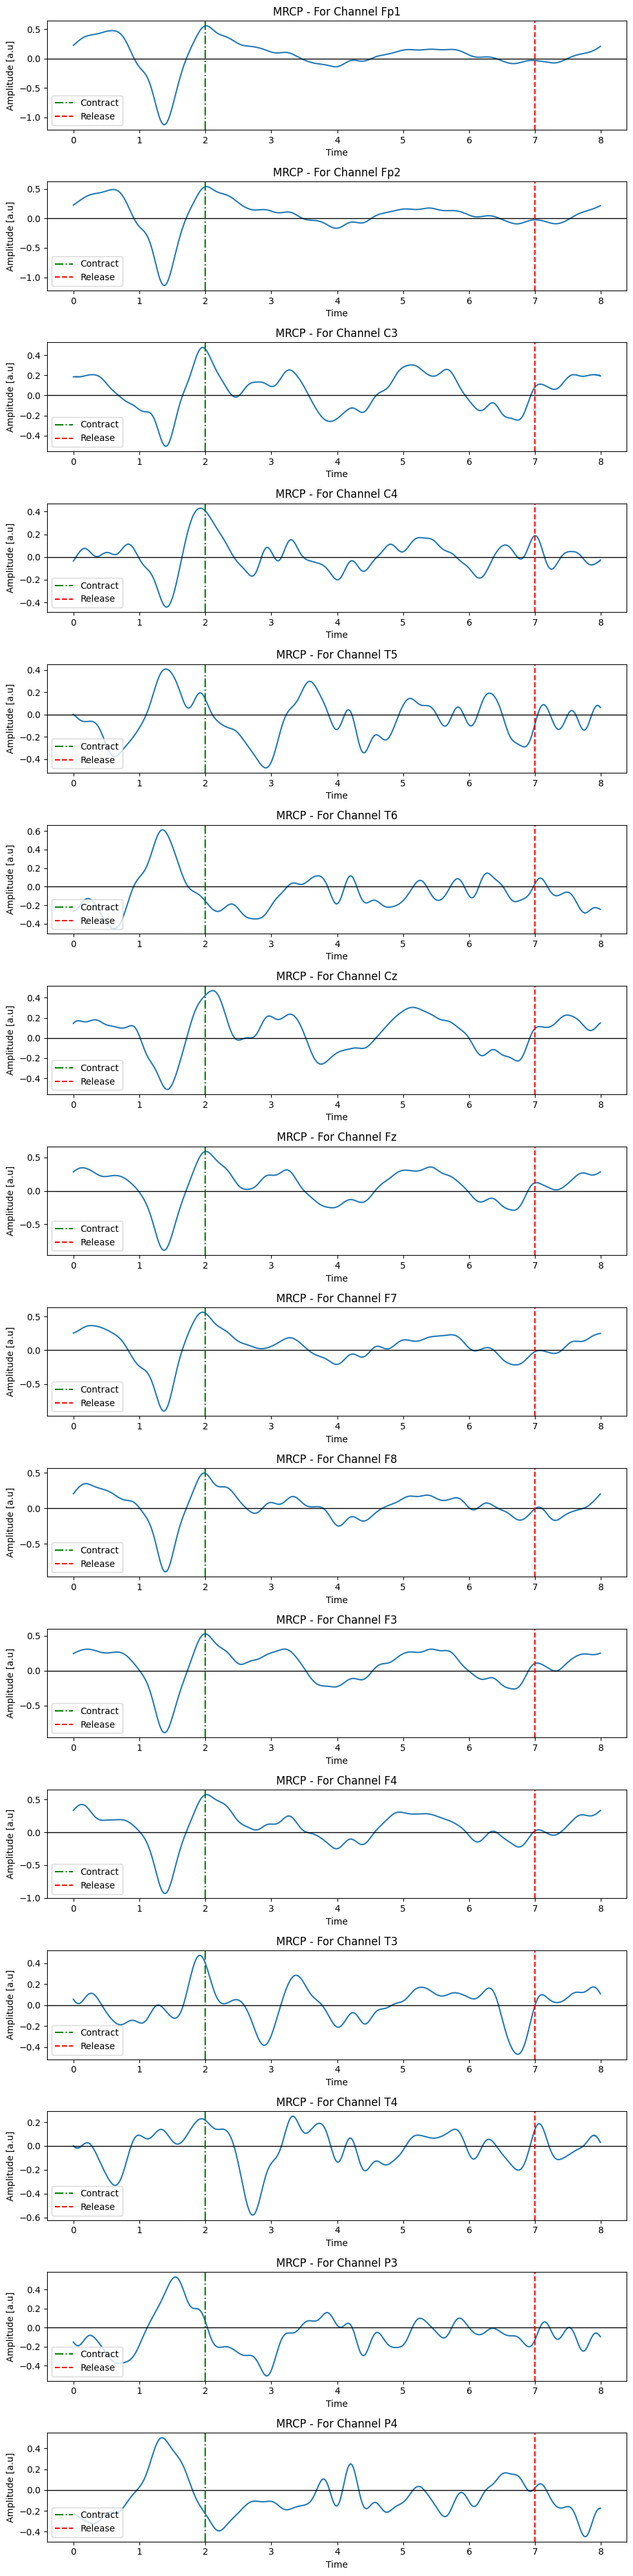

In [81]:
plot_mrcp_across_channels_together(THUMB_epoch_mean)

## EXPERIMENTS TO TEST
* Only listen to tones (BUT THEY INTRODUCE DELAY...)
* Perform only using text display (Open eyes)
* Is the data shifted reason the trimming implementation?